In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Part A

In [41]:
df = pd.read_csv('house_price_analysis.csv')

In [16]:
df.head()

,Area,Bedrooms,Bathrooms,Age,Parking,LocationScore,Price
0,900,2,1,10,1,6,3200000
1,1100,2,2,8,1,7,4200000
2,1400,3,2,6,1,8,5500000
3,1600,3,3,5,2,9,6800000
4,1800,4,3,4,2,9,7600000


In [17]:
df.shape

(15, 7)

In [18]:
print(df.columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Parking', 'LocationScore',
       'Price'],
      dtype='object')


In [19]:
df.dtypes

Area             int64
Bedrooms         int64
Bathrooms        int64
Age              int64
Parking          int64
LocationScore    int64
Price            int64
dtype: object

In [20]:
df.isnull().sum()

Area             0
Bedrooms         0
Bathrooms        0
Age              0
Parking          0
LocationScore    0
Price            0
dtype: int64

In [21]:
df.drop_duplicates(inplace= True)

In [22]:
df.describe()

,Area,Bedrooms,Bathrooms,Age,Parking,LocationScore,Price
count,15.000000,15.000000,15.000000,15.00000,15.000000,15.00000,1.500000e+01
mean,1463.333333,3.133333,2.400000,5.80000,1.666667,8.00000,6.033333e+06
std,374.388390,0.915475,0.985611,3.27763,0.723747,1.36277,2.047530e+06
min,900.000000,2.000000,1.000000,1.00000,1.000000,6.00000,3.200000e+06
25%,1175.000000,2.500000,2.000000,3.50000,1.000000,7.00000,4.550000e+06
50%,1500.000000,3.000000,2.000000,5.00000,2.000000,8.00000,6.100000e+06
75%,1725.000000,4.000000,3.000000,7.50000,2.000000,9.00000,7.400000e+06
max,2100.000000,5.000000,4.000000,12.00000,3.000000,10.00000,9.800000e+06


# Part B

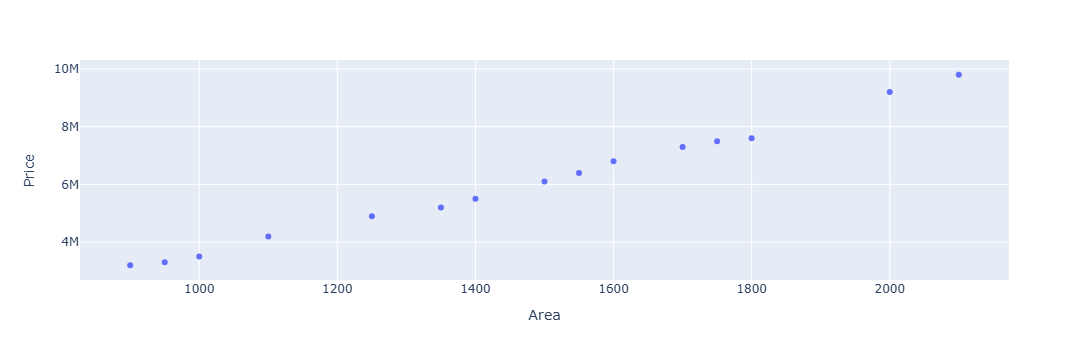

In [58]:
import plotly.express as px
import plotly.io as pio
pio.defaults.renderer = 'notebook'

fig = px.scatter(df, 'Area', 'Price')
fig.show()

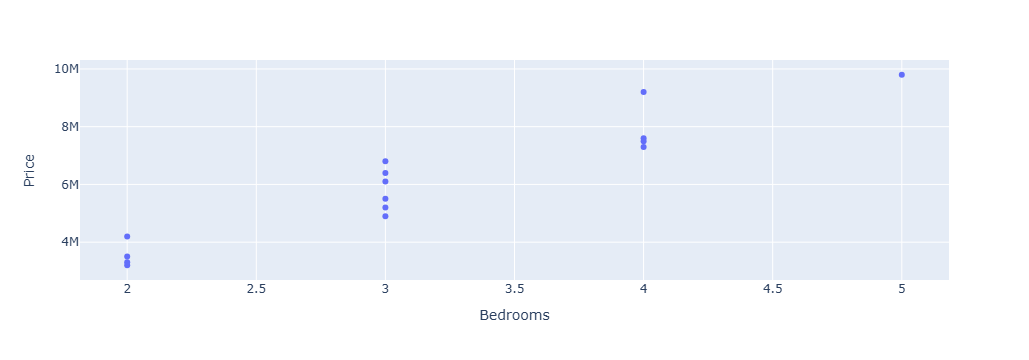

In [59]:
fig1 = px.scatter(df, 'Bedrooms', 'Price')
fig1.show()

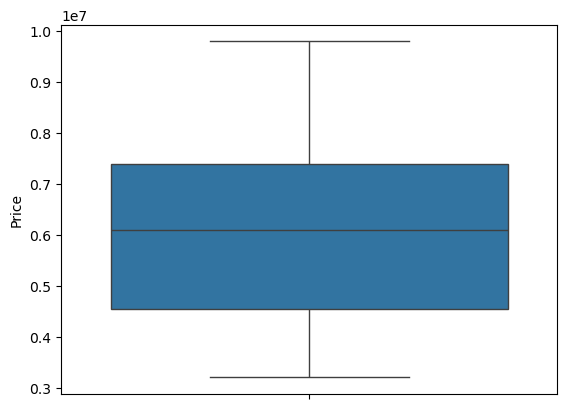

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(df['Price'])
plt.show()

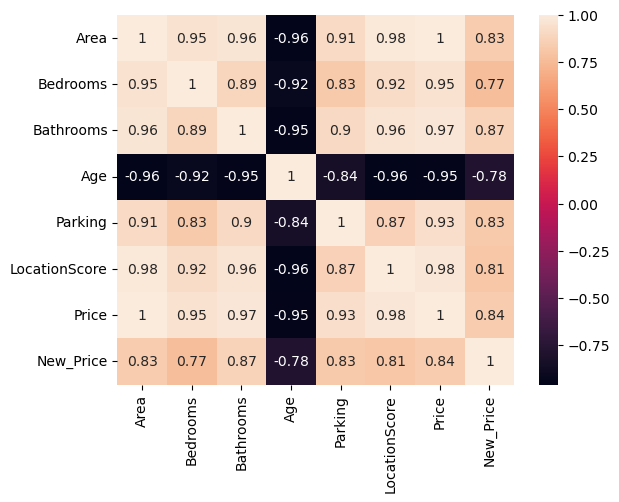

In [64]:
sns.heatmap(df.corr(), annot = True)
plt.show()

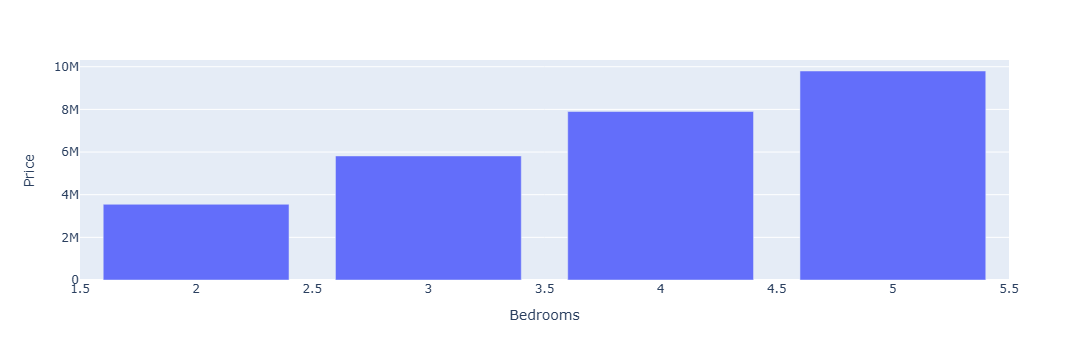

In [71]:
fig2 = px.bar(df.groupby('Bedrooms')['Price'].mean().reset_index(), 'Bedrooms', 'Price')
fig2.show()

# Part C

In [27]:
X_linear = df[['Area']]
y_linear = df['Price']

Xtrain_linear, Xtest_linear, ytrain_linear, ytest_linear = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)

model_linear = LinearRegression().fit(Xtrain_linear, ytrain_linear)
ypred_linear = model_linear.predict(Xtest_linear)

print(r2_score(ytest_linear, ypred_linear))
print(mean_absolute_error(ytest_linear, ypred_linear))
print(mean_squared_error(ytest_linear, ypred_linear))
print(root_mean_squared_error(ytest_linear, ypred_linear))


0.9906476551249069
239106.14525139704
58192368111.69043
241230.94352029226


In [29]:
X_multi = df.drop(columns = ['Price'])
y_multi = df['Price']

Xtrain_multi, Xtest_multi, ytrain_multi, ytest_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression().fit(Xtrain_multi, ytrain_multi)
ypred_multi = model_multi.predict(Xtest_multi)

print(r2_score(ytest_multi, ypred_multi))
print(mean_absolute_error(ytest_multi, ypred_multi))
print(mean_squared_error(ytest_multi, ypred_multi))
print(root_mean_squared_error(ytest_multi, ypred_multi))

0.9981179806604562
88640.87301587251
11710342557.161705
108214.3361905515


In [33]:
poly = PolynomialFeatures(degree=3)

X_poly = df[['Area']]
y_poly = df['Price']

Xtrain_poly, Xtest_poly, ytrain_poly, ytest_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

Xtrain_poly = poly.fit_transform(Xtrain_poly)
Xtest_poly = poly.transform(Xtest_poly)

model_poly = LinearRegression().fit(Xtrain_poly, ytrain_poly)
ypred_poly = model_poly.predict(Xtest_poly)

print(r2_score(ytest_poly, ypred_poly))
print(mean_absolute_error(ytest_poly, ypred_poly))
print(mean_squared_error(ytest_poly, ypred_poly))
print(root_mean_squared_error(ytest_poly, ypred_poly))

0.994479351788869
183292.08240128183
34350699980.370636
185339.418312378


In [42]:
med = df['Price'].median()
df['New_Price'] = np.where(df['Price'] > med, 1, 0)
df

,Area,Bedrooms,Bathrooms,Age,Parking,LocationScore,Price,New_Price
0,900,2,1,10,1,6,3200000,0
1,1100,2,2,8,1,7,4200000,0
2,1400,3,2,6,1,8,5500000,0
3,1600,3,3,5,2,9,6800000,1
4,1800,4,3,4,2,9,7600000,1
5,1000,2,1,12,1,6,3500000,0
6,1250,3,2,7,1,7,4900000,0
7,1500,3,2,5,2,8,6100000,0
8,1700,4,3,3,2,9,7300000,1
9,2000,4,4,2,3,10,9200000,1


In [53]:
X_knn = df.drop(columns = ['New_Price','Price'])
y_knn = df['New_Price']

Xtrain_knn, Xtest_knn, ytrain_knn, ytest_knn = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

model_knn = KNeighborsClassifier(n_neighbors=3).fit(Xtrain_knn, ytrain_knn)
ypred_knn = model_knn.predict(Xtest_knn)

print(accuracy_score(ytest_knn, ypred_knn))
print(precision_score(ytest_knn, ypred_knn))
print(recall_score(ytest_knn, ypred_knn))
print(f1_score(ytest_knn, ypred_knn))
print(confusion_matrix(ytest_knn, ypred_knn))


1.0
1.0
1.0
1.0
[[2 0]
 [0 1]]


In [52]:
X_dt = df.drop(columns = ['New_Price','Price'])
y_dt = df['New_Price']

Xtrain_dt, Xtest_dt, ytrain_dt, ytest_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)

model_dt = DecisionTreeClassifier(criterion='entropy', max_depth=5).fit(Xtrain_dt, ytrain_dt)
ypred_dt = model_dt.predict(Xtest_dt)

print(accuracy_score(ytest_dt, ypred_dt))
print(precision_score(ytest_dt, ypred_dt))
print(recall_score(ytest_dt, ypred_dt))
print(f1_score(ytest_dt, ypred_dt))
print(confusion_matrix(ytest_dt, ypred_dt))

1.0
1.0
1.0
1.0
[[2 0]
 [0 1]]


In [50]:
df_regression = pd.DataFrame([['Simple LR', mean_absolute_error(ytest_linear, ypred_linear), mean_squared_error(ytest_linear, ypred_linear), root_mean_squared_error(ytest_linear, ypred_linear), r2_score(ytest_linear, ypred_linear)],['Multiple LR',mean_absolute_error(ytest_multi, ypred_multi), mean_squared_error(ytest_multi, ypred_multi), root_mean_squared_error(ytest_multi, ypred_multi), r2_score(ytest_multi, ypred_multi)],['Multiple LR',mean_absolute_error(ytest_poly, ypred_poly), mean_squared_error(ytest_poly, ypred_poly), root_mean_squared_error(ytest_poly, ypred_poly), r2_score(ytest_poly, ypred_poly)]], columns=['Model','MAE','MSE','RMSE','R2 Score'])
df_regression

,Model,MAE,MSE,RMSE,R2 Score
0,Simple LR,239106.145251,5.819237e+10,241230.943520,0.990648
1,Multiple LR,88640.873016,1.171034e+10,108214.336191,0.998118
2,Multiple LR,183292.082401,3.435070e+10,185339.418312,0.994479


In [54]:
df_classification = pd.DataFrame([['KNN', accuracy_score(ytest_knn, ypred_knn), precision_score(ytest_knn, ypred_knn), recall_score(ytest_knn, ypred_knn), f1_score(ytest_knn, ypred_knn)],['Decision Tree',accuracy_score(ytest_dt, ypred_dt), precision_score(ytest_dt, ypred_dt), recall_score(ytest_dt, ypred_dt), f1_score(ytest_dt, ypred_dt)]], columns=['Model','Accuracy','Precision','Recall','F1 Score'])
df_classification

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0


In [3]:
df = pd.read_csv('CSV/Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [4]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [5]:
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.drop(columns=['customerID'], inplace=True)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [8]:
df = pd.get_dummies(df, drop_first=True)
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,False,True,True,False,True,False,False,True,False
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,False,True,True,False,True,True,False,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,True,False,True,False,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,True,False,False,True,True


In [15]:
X = df.drop(columns=['Churn_Yes'])
y = df['Churn_Yes']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

acc = []

for i in np.arange(50): # 0.7963094393186657
    model = KNeighborsClassifier(n_neighbors=i + 1).fit(Xtrain, ytrain)
    ypred = model.predict(Xtest)
    acc.append(accuracy_score(ytest, ypred))

print(acc.index(max(acc)))
model = KNeighborsClassifier(n_neighbors=acc.index(max(acc))).fit(Xtrain, ytrain)
ypred = model.predict(Xtest)
print(accuracy_score(ytest, ypred))

TN, FP, FN, TP = confusion_matrix(ytest, ypred).ravel()
recall = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP) 
print(confusion_matrix(ytest, ypred))
print(recall)
print(specificity)
print(precision)

23
0.794889992902768
[[960  76]
 [213 160]]
0.4289544235924933
0.9266409266409267
0.6779661016949152


In [18]:
X = df.drop(columns=['Churn_Yes'])
y = df['Churn_Yes']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

acc = []

for i in np.arange(50): # 0.7963094393186657
    model = DecisionTreeClassifier(max_depth=i + 1).fit(Xtrain, ytrain)
    ypred = model.predict(Xtest)
    acc.append(accuracy_score(ytest, ypred))

print(acc.index(max(acc)))
model = DecisionTreeClassifier(max_depth=acc.index(max(acc))).fit(Xtrain, ytrain)
ypred = model.predict(Xtest)
print(accuracy_score(ytest, ypred))

TN, FP, FN, TP = confusion_matrix(ytest, ypred).ravel()
recall = TP / (TP + FN)
specificity = TN / (TN + FP)
precision = TP / (TP + FP) 
print(confusion_matrix(ytest, ypred))
print(recall)
print(specificity)
print(precision)

4
0.8026969481902059
[[934 102]
 [176 197]]
0.5281501340482574
0.9015444015444015
0.6588628762541806


In [19]:
from sklearn.svm import SVC

In [ ]:
# 